<div class="alert alert-block alert-info">
  <center> <h1> Exploratory Data Analysis 
  - Amazing International Airlines Inc. </h1> </center> <br>
  <center> <h2> Group 92 </h2> </center> <br>
  <center <h3> notebook  </h3> </center>
  <center> <h3> 2025/2026 </h3> </center>
</div>


This Project was done by:


Student Name    -   Mehmet Karaca
student id      -   20250344
contact email   -   mehmet.karaca@example.com

Student Name    -   Duarte Gomes
student id      -   3423414
contact email   -   duarte.gomes@example.com

Student Name    -   Esra salih
student id      -   123567
contact email   -   esra.salih@example.com

# Table of Content



**0. [Context and Metadata](#0-context)**  

**1. [Importing Libraries and Loading Data](#importing-libraries-and-data)**  
   - [1.1 Importing Libraries](#importing-libraries)  
   - [1.2 Loading and Reading Data](#loading-and-reading-data)  
   - [1.3 Brief Preliminary Analysis](#brief-preliminary-analysis)
- **2. [Exploratory Data Analysis (EDA)](#exploratory-data-analysis-eda)** 

   - **2.1. [Validity check of the column values](#validity-check)**  
      - [2.1.1. Checking for Missing Values](#missing-values)  
      - [2.1.2. Checking for Duplicates](#duplicates)  
      - [2.1.3. Checking for Outliers](#outliers)
  




# 0. Context and Metadata <a class="anchor" id="0-context"></a>

Text text text

Metadata

CustomerDB 


FlightsDB

Examples:

`customer_id` - Unique identifier for each customer <br>
`customer_region` - Geographic region where the customer is located <br>
`customer_age` - Age of the customer <br>
`vendor_count` - Number of unique vendors the customer has ordered from <br>
`product_count` - Total number of products the customer has ordered <br>
`is_chain` - Indicates whether the customer’s order was from a chain restaurant <br>
`first_order` - Number of days from the start of the dataset when the customer first placed an order. <br>
`last_order` - Number of days from the start of the dataset when the customer most recently placed an order. <br>
`last_promo` - The category of the promotion or discount most recently used by the customer. <br>
`payment_method` - Method most recently used by the customer to pay for their orders. <br>
`CUI_(cuisine)`- The amount in monetary units spent by the customer from the indicated type of cuisine. <br>
- CUI_Beverages, CUI_Cafe', 'CUI_Chicken Dishes', 'CUI_Chinese', 'CUI_Desserts','CUI_Healthy', 'CUI_Indian', 'CUI_Italian', 'CUI_Japanese', 'CUI_Noodle Dishes', 'CUI_OTHER', 'CUI_Street Food / Snacks', CUI_Thai <br>

`DOW_0 to DOW_6` - Number of orders placed on each day of the week (0 = Sunday, 6 = Saturday). <br>
`HR_0 to HR_23` - Number of orders placed during each hour of the day (0 = midnight, 23 = 11 PM). <br>
ders.

## 1.1. Importing Libraries <a class="anchor" id="importing-libraries"></a>

In [1]:
# --- Standard Imports
import os
from pathlib import Path
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import plotly.express as px
import matplotlib
import math

## 1.2. loading and Reading Data <a class="anchor" id="loading-and-reading-data"></a>

In [2]:
# directory with raw CSV files
data_dir = Path("../data/raw")

# list all CSV files
csv_files = list(data_dir.glob("*.csv"))
print(f"Found CSV files: {[f.name for f in csv_files]}")


Found CSV files: ['DM_AIAI_CustomerDB.csv', 'DM_AIAI_Metadata.csv', 'DM_AIAI_FlightsDB.csv']


In [3]:
# specify the files we want to load

customers_file = data_dir / "DM_AIAI_CustomerDB.csv"
flights_file   = data_dir / "DM_AIAI_FlightsDB.csv"

# load them with pandas
customers = pd.read_csv(customers_file)
flights   = pd.read_csv(flights_file)

print("Customers shape:", customers.shape)
print("Flights shape:", flights.shape)

Customers shape: (16921, 21)
Flights shape: (608436, 10)


## 1.3. Brief Preliminary Analysis <a class="anchor" id="brief-preliminary-analysis"></a>

In [4]:
customers.columns

Index(['Unnamed: 0', 'Loyalty#', 'First Name', 'Last Name', 'Customer Name',
       'Country', 'Province or State', 'City', 'Latitude', 'Longitude',
       'Postal code', 'Gender', 'Education', 'Location Code', 'Income',
       'Marital Status', 'LoyaltyStatus', 'EnrollmentDateOpening',
       'CancellationDate', 'Customer Lifetime Value', 'EnrollmentType'],
      dtype='object')

In [5]:
customers.info

<bound method DataFrame.info of        Unnamed: 0  Loyalty# First Name    Last Name        Customer Name  \
0               0    480934    Cecilia  Householder  Cecilia Householder   
1               1    549612      Dayle        Menez          Dayle Menez   
2               2    429460     Necole       Hannon        Necole Hannon   
3               3    608370      Queen        Hagee          Queen Hagee   
4               4    530508     Claire      Latting       Claire Latting   
...           ...       ...        ...          ...                  ...   
16916          15    100012      Ethan     Thompson       Ethan Thompson   
16917          16    100013      Layla        Young          Layla Young   
16918          17    100014     Amelia      Bennett       Amelia Bennett   
16919          18    100015   Benjamin       Wilson      Benjamin Wilson   
16920          19    100016       Emma       Martin          Emma Martin   

      Country Province or State          City   Latitud

In [6]:
customers.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,16921.0,8440.023639,4884.775439,0.000000,4210.000000,8440.000000,12670.000000,16900.000000
Loyalty#,16921.0,550197.393771,259251.503597,100011.000000,326823.000000,550896.000000,772438.000000,999999.000000
Latitude,16921.0,47.174500,3.307971,42.984924,44.231171,46.087818,49.282730,60.721188
Longitude,16921.0,-91.814768,22.242429,-135.056840,-120.237660,-79.383186,-74.596184,-52.712578
Income,16901.0,37758.038400,30368.992499,0.000000,0.000000,34161.000000,62396.000000,99981.000000
Customer Lifetime Value,16901.0,7990.460188,6863.173093,1898.010000,3979.720000,5780.180000,8945.690000,83325.380000


In [7]:
customers.describe(include='object').T

,count,unique,top,freq
First Name,16921,4941,Deon,13
Last Name,16921,15404,Salberg,4
Customer Name,16921,16921,Cecilia Householder,1
Country,16921,1,Canada,16921
Province or State,16921,11,Ontario,5468
City,16921,29,Toronto,3390
Postal code,16921,75,V6E 3D9,917
Gender,16921,2,female,8497
Education,16921,5,Bachelor,10586
Location Code,16921,3,Suburban,5716


In [8]:
flights.columns

Index(['Loyalty#', 'Year', 'Month', 'YearMonthDate', 'NumFlights',
       'NumFlightsWithCompanions', 'DistanceKM', 'PointsAccumulated',
       'PointsRedeemed', 'DollarCostPointsRedeemed'],
      dtype='object')

In [9]:
flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608436 entries, 0 to 608435
Data columns (total 10 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Loyalty#                  608436 non-null  int64  
 1   Year                      608436 non-null  int64  
 2   Month                     608436 non-null  int64  
 3   YearMonthDate             608436 non-null  object 
 4   NumFlights                608436 non-null  float64
 5   NumFlightsWithCompanions  608436 non-null  float64
 6   DistanceKM                608436 non-null  float64
 7   PointsAccumulated         608436 non-null  float64
 8   PointsRedeemed            608436 non-null  float64
 9   DollarCostPointsRedeemed  608436 non-null  float64
dtypes: float64(6), int64(3), object(1)
memory usage: 46.4+ MB


In [10]:
flights.describe().T

,count,mean,std,min,25%,50%,75%,max
Loyalty#,608436.0,550037.873084,258935.180575,100018.0,326961.00,550834.000,772194.0000,999986.0
Year,608436.0,2020.000000,0.816497,2019.0,2019.00,2020.000,2021.0000,2021.0
Month,608436.0,6.500000,3.452055,1.0,3.75,6.500,9.2500,12.0
NumFlights,608436.0,3.908107,5.057889,0.0,0.00,0.000,7.2000,21.0
NumFlightsWithCompanions,608436.0,0.983944,2.003785,0.0,0.00,0.000,0.9000,11.0
DistanceKM,608436.0,7939.341419,10260.421873,0.0,0.00,856.400,15338.1750,42040.0
PointsAccumulated,608436.0,793.777781,1025.918521,0.0,0.00,85.275,1533.7125,4204.0
PointsRedeemed,608436.0,235.251678,983.233374,0.0,0.00,0.000,0.0000,7496.0
DollarCostPointsRedeemed,608436.0,2.324835,9.725168,0.0,0.00,0.000,0.0000,74.0


In [11]:
flights.describe(include='object').T

,count,unique,top,freq
YearMonthDate,608436,36,12/1/2021,16901


Remove the column "Unnamed: 0" because it is not needed and has no context in the data.

In [12]:
if "Unnamed: 0" in customers.columns:
	customers.drop(columns=["Unnamed: 0"], inplace=True)

# 2. Missing Values and Data Validity Check  <a class="anchor" id="Data_Validity_Check"></a>


Some text to describe what we are doing here.

In [13]:
# Converting the datatype of categorical features from object to category

flights['YearMonthDate'] = pd.to_datetime(flights['YearMonthDate'], format='%m/%d/%Y')


# Convert NumFlights and NumFlightsWithCompanions to integer type (they are float by default)
flights["NumFlights"] = flights["NumFlights"].astype(int)
flights["NumFlightsWithCompanions"] = flights["NumFlightsWithCompanions"].astype(int)

In [14]:
# Check the datatype of YearMonthDate column
flights['YearMonthDate'].dtype

dtype('<M8[ns]')

## 2.1. Missing Values <a class="anchor" id="missing-values"></a>

Some text to describe what we are doing here.

In [15]:
# Check for missing values
print("Missing values in CustomerDB:")
display(customers.isna().sum())

print("\nMissing values in FlightsDB:")
display(flights.isna().sum())


Missing values in CustomerDB:


Loyalty#                       0
First Name                     0
Last Name                      0
Customer Name                  0
Country                        0
Province or State              0
City                           0
Latitude                       0
Longitude                      0
Postal code                    0
Gender                         0
Education                      0
Location Code                  0
Income                        20
Marital Status                 0
LoyaltyStatus                  0
EnrollmentDateOpening          0
CancellationDate           14611
Customer Lifetime Value       20
EnrollmentType                 0
dtype: int64


Missing values in FlightsDB:


Loyalty#                    0
Year                        0
Month                       0
YearMonthDate               0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
dtype: int64

In [16]:
missing_ratio = customers.isna().mean().sort_values(ascending=False)
print((missing_ratio * 100).round(2))

CancellationDate           86.35
Customer Lifetime Value     0.12
Income                      0.12
Loyalty#                    0.00
First Name                  0.00
EnrollmentDateOpening       0.00
LoyaltyStatus               0.00
Marital Status              0.00
Location Code               0.00
Education                   0.00
Gender                      0.00
Postal code                 0.00
Longitude                   0.00
Latitude                    0.00
City                        0.00
Province or State           0.00
Country                     0.00
Customer Name               0.00
Last Name                   0.00
EnrollmentType              0.00
dtype: float64


The flights dataset is clean. The customers dataset has missing values in the columns "CancellationDate", "Customer Lifetime Value" and "Income". We start with analyzing the CancellationDate column. We expect that, these missing values correspond to customers who have not cancelled their subscription. We will check this assumption by looking at some entries with missing CancellationDate values.

In [17]:
# select first 10 rows where CancellationDate is NaN
active_customers = customers[customers["CancellationDate"].isna()].head(10)
active_customers

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,Urban,70146.0,Married,Star,2/15/2019,NaN,3839.14,Standard
1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,Rural,0.0,Divorced,Star,3/9/2019,NaN,3839.61,Standard
3,608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,Suburban,0.0,Single,Star,2/17/2016,NaN,3839.75,Standard
4,530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,Suburban,97832.0,Married,Star,10/25/2017,NaN,3842.79,2021 Promotion
5,193662,Leatrice,Hanlin,Leatrice Hanlin,Canada,Yukon,Whitehorse,60.721188,-135.056840,Y2K 6R0,male,Bachelor,Rural,26262.0,Married,Star,5/7/2015,NaN,3844.57,Standard
6,927943,Hue,Sellner,Hue Sellner,Canada,Ontario,Toronto,43.653225,-79.383186,P5S 6R4,female,College,Urban,0.0,Single,Star,6/9/2017,NaN,3857.95,Standard
7,188893,Nakia,Cash,Nakia Cash,Canada,Ontario,Trenton,44.101128,-77.576309,K8V 4B2,male,Bachelor,Suburban,93272.0,Married,Star,12/8/2019,NaN,3861.49,Standard
8,852392,Arlene,Conterras,Arlene Conterras,Canada,Quebec,Montreal,45.501690,-73.567253,H2Y 2W2,female,Bachelor,Suburban,93272.0,Married,Star,5/30/2018,NaN,3861.49,Standard
9,866307,Dustin,Recine,Dustin Recine,Canada,Ontario,Toronto,43.653225,-79.383186,M8Y 4K8,male,Bachelor,Suburban,93272.0,Married,Star,10/14/2019,NaN,3861.49,Standard
10,932823,Jeremy,Dickason,Jeremy Dickason,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,female,Bachelor,Suburban,47199.0,Married,Star,3/17/2018,NaN,3863.31,Standard


The Entries seem to look fine. The expectation seems to be correct. We will add a new column in the Data Engineering section to indicate whether a customer is active or not based on the CancellationDate column.

Next we check the missing values in the "Customer Lifetime Value" and "Income" columns. 

In [18]:
# rows where Income is missing
missing_income = customers[customers["Income"].isna()]
print("Rows with missing Income:", missing_income.shape[0])
display(missing_income.head(5))

Rows with missing Income: 20


,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
16901,999987,Layla,Murphy,Layla Murphy,Canada,New Brunswick,Fredericton,46.029263,-66.565150,R4H 2Y2,female,Bachelor,Urban,NaN,Single,Star,3/7/2017,3/7/2017,NaN,Standard
16902,999988,Jana,Parker,Jana Parker,Canada,Quebec,Montreal,45.573672,-73.523012,N6B 1N3,male,College,Rural,NaN,Single,Star,8/22/2017,8/22/2017,NaN,Standard
16903,999989,Ethan,Parker,Ethan Parker,Canada,Ontario,Trenton,44.075379,-77.550375,P8F 5C8,male,College,Rural,NaN,Married,Star,9/12/2015,9/12/2015,NaN,Standard
16904,999990,Ryan,Anderson,Ryan Anderson,Canada,New Brunswick,Moncton,46.106617,-64.714267,B6P 6D0,female,College,Rural,NaN,Married,Star,6/10/2019,6/10/2019,NaN,Standard
16905,999991,Olivia,Cote,Olivia Cote,Canada,New Brunswick,Fredericton,45.950000,-66.652437,X3W 5N2,female,College,Suburban,NaN,Married,Star,7/20/2019,7/20/2019,NaN,Standard


In [19]:
# rows where Customer Lifetime Value is missing
missing_clv = customers[customers["Customer Lifetime Value"].isna()]
print("Rows with missing Customer Lifetime Value:", missing_clv.shape[0])
display(missing_clv.head(5))

Rows with missing Customer Lifetime Value: 20


,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Location Code,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
16901,999987,Layla,Murphy,Layla Murphy,Canada,New Brunswick,Fredericton,46.029263,-66.565150,R4H 2Y2,female,Bachelor,Urban,NaN,Single,Star,3/7/2017,3/7/2017,NaN,Standard
16902,999988,Jana,Parker,Jana Parker,Canada,Quebec,Montreal,45.573672,-73.523012,N6B 1N3,male,College,Rural,NaN,Single,Star,8/22/2017,8/22/2017,NaN,Standard
16903,999989,Ethan,Parker,Ethan Parker,Canada,Ontario,Trenton,44.075379,-77.550375,P8F 5C8,male,College,Rural,NaN,Married,Star,9/12/2015,9/12/2015,NaN,Standard
16904,999990,Ryan,Anderson,Ryan Anderson,Canada,New Brunswick,Moncton,46.106617,-64.714267,B6P 6D0,female,College,Rural,NaN,Married,Star,6/10/2019,6/10/2019,NaN,Standard
16905,999991,Olivia,Cote,Olivia Cote,Canada,New Brunswick,Fredericton,45.950000,-66.652437,X3W 5N2,female,College,Suburban,NaN,Married,Star,7/20/2019,7/20/2019,NaN,Standard


In [20]:
# Check if the missing values in Income and Customer Lifetime Value overlap
missing_income_indices = set(missing_income.index)
missing_clv_indices = set(missing_clv.index)
overlapping_indices = missing_income_indices.intersection(missing_clv_indices)

print("Rows with missing values in both Income and Customer Lifetime Value:", len(overlapping_indices))

Rows with missing values in both Income and Customer Lifetime Value: 20


The missing values in Income and Customer Lifetime Value do overlap fully. This means that all rows with missing Income also have missing Customer Lifetime Value. This could indicate a correlation between the two columns, or it could be due to data collection issues. Only 20 rows are affected, which is a small fraction of the total dataset. Deleting these rows might be a reasonable approach for the second part of the project. But for now we will keep them as is.

## 2.2. Validity check <a class="anchor" id="validity-check"></a>

We check all the columns for validity of the values. 

### 2.2.1 Categorical Features of customers <a class="anchor" id="categorical-features"></a>

In [21]:
# List all categorical columns in customers
cat_columns_customers = customers.select_dtypes(include=['object']).columns.tolist()
cat_columns_customers

['First Name',
 'Last Name',
 'Customer Name',
 'Country',
 'Province or State',
 'City',
 'Postal code',
 'Gender',
 'Education',
 'Location Code',
 'Marital Status',
 'LoyaltyStatus',
 'EnrollmentDateOpening',
 'CancellationDate',
 'EnrollmentType']

In [22]:
# Check the categorical columns for unexpected values
for col in ["Gender","Country", "Education", "Marital Status","LoyaltyStatus", "Province or State", "City", "EnrollmentType"]:
    if col in customers.columns:
        print(f"\n{col} categories:")
        print(customers[col].value_counts(dropna=False))


Gender categories:
Gender
female    8497
male      8424
Name: count, dtype: int64

Country categories:
Country
Canada    16921
Name: count, dtype: int64

Education categories:
Education
Bachelor                10586
College                  4283
High School or Below      792
Doctor                    742
Master                    518
Name: count, dtype: int64

Marital Status categories:
Marital Status
Married     9842
Single      4539
Divorced    2540
Name: count, dtype: int64

LoyaltyStatus categories:
LoyaltyStatus
Star      7761
Nova      5722
Aurora    3438
Name: count, dtype: int64

Province or State categories:
Province or State
Ontario                 5468
British Columbia        4416
Quebec                  3311
Alberta                 1008
Manitoba                 676
New Brunswick            652
Nova Scotia              541
Saskatchewan             412
Newfoundland             258
Yukon                    112
Prince Edward Island      67
Name: count, dtype: int64

City categ

In [23]:
# Check for postal codes
print("Unique postal codes:", customers["Postal code"].nunique())
print(customers["Postal code"].value_counts().head(10))

#Check if Postal code has entries with more or less than 7 characters
long_postal_codes = customers[customers["Postal code"].astype(str).str.len() > 7]
print("Postal codes with more than 7 characters:", long_postal_codes.shape[0])
short_postal_codes = customers[customers["Postal code"].astype(str).str.len() < 7]
print("Postal codes with less than 7 characters:", short_postal_codes.shape[0])


Unique postal codes: 75
Postal code
V6E 3D9    917
V5R 1W3    699
V6T 1Y8    586
V6E 3Z3    538
M2M 7K8    538
P1J 8T7    508
H2T 9K8    503
K8V 4B2    490
G1B 3L5    481
H2T 2J6    449
Name: count, dtype: int64
Postal codes with more than 7 characters: 0
Postal codes with less than 7 characters: 0


Check of the unique values in categorical columns to see if they make sense.

- Gender: Only male and female --> valid
- Country: Only Canada --> valid
- Education: Only valid education levels --> valid
- Marital Status: Only valid marital statuses --> valid
- LoyaltyStatus: Only valid loyalty statuses --> valid
- Province or State: Only valid provinces or states in Canada --> valid
- City: Only valid cities in Canada --> valid
- EnrollmentType: Only valid enrollment types --> valid

### 2.2.2 Numerical Features of customers <a class="anchor" id="numerical-features-customers"></a>

In [24]:
# Min and Max Values of each column of customers db
numeric_cols = customers.select_dtypes(include=["number"]).columns

min_max = customers[numeric_cols].agg(["min", "max"]).T
min_max.transpose()


,Loyalty#,Latitude,Longitude,Income,Customer Lifetime Value
min,100011.0,42.984924,-135.056840,0.0,1898.01
max,999999.0,60.721188,-52.712578,99981.0,83325.38


- Loyalty#: Is the unique identifier for each customer. Check if unique
- Lattitude and Longitude make sense because it is only data from Canada (Longitutde: -52 to -141, Latitude: 41 to 83)
- Income has no negative values, but needs to be checked for outliers
- Customer Lifetime Value has no negative values, but needs to be checked for outliers
- IsActive makes sense because it is only 0 and 1


Next we check for unique loyalty# 

In [25]:
# Check uniqueness of Loyalty in customers
n_rows = customers.shape[0]
n_unique_ids = customers["Loyalty#"].nunique()

print("Rows in CustomerDB:", n_rows)
print("Unique Loyalty IDs:", n_unique_ids)

if n_rows == n_unique_ids:
    print("Loyalty is unique per row.")
else:
    print ("There are", n_rows - n_unique_ids - 1, "duplicated Loyalty values.")


Rows in CustomerDB: 16921
Unique Loyalty IDs: 16757
There are 163 duplicated Loyalty values.


- There are some duplicated Loyalty values in the customers dataset. We have to check if these are really duplicates or if there are different customers with the same loyalty id. If they are duplicates, we have to delete them.

In [26]:
# List of the inconsistent Loyalty IDs in customers dataset
duplicates_by_name = customers[customers.duplicated(subset=["Loyalty#"], keep=False)].sort_values(by=["Loyalty#"])
duplicates_by_name[['Loyalty#', 'First Name', 'Last Name']]

,Loyalty#,First Name,Last Name
1646,101902,Hans,Schlottmann
2668,101902,Yi,Nesti
15988,106001,Maudie,Hyland
700,106001,Ivette,Peifer
13053,106509,Stacy,Schwebke
...,...,...,...
5038,989528,Sharri,Boughman
9890,990512,Magda,Sopher
14478,990512,Ione,Snowden
6981,992168,Frederick,Samaha


- That means that different customers have the same loyalty id. This is a problem because we cannot identify the customers uniquely and can not map their flights correctly. We check how many entries in flights correspond to these inconsistent loyalty ids.
  

In [27]:
# Count the number of entries in flights corresponding to the inconsistent loyalty ids in total
inconsistent_loyalty_ids = duplicates_by_name['Loyalty#'].unique()
flights_inconsistent = flights[flights['Loyalty#'].isin(inconsistent_loyalty_ids)]
flights_inconsistent_count = flights_inconsistent['Loyalty#'].value_counts()
flights_inconsistent_count.sum()
print("Number of flight entries with inconsistent loyalty IDs:", flights_inconsistent_count.sum())

# Percentage of flights affected by inconsistent loyalty ids
total_flights = flights.shape[0]
affected_percentage = (flights_inconsistent_count.sum() / total_flights) * 100
print(f"Percentage of flights affected by inconsistent loyalty IDs: {affected_percentage:.2f}%")

Number of flight entries with inconsistent loyalty IDs: 11772
Percentage of flights affected by inconsistent loyalty IDs: 1.93%


- One Major problem of these duplicated loyalty ids is, that we cannot link the customers to their flights. There is no reasonable way to differentiate between the two customers with the same loyalty id. So that the even changing the loyalty id of one customer would not help, because we still do not know which flights belong to which customer. We would create a new customer with a new loyalty id, but this customer would have no flights linked to him. So we would loose all the information about the flights of these customers and the other customer would have all the flights linked to him. This would distort the data and make it unusable for analysis.
  
- So for this reason we have to delete all customers with duplicated loyalty ids and all their flights. This is the only way to ensure that the remaining data is valid and can be used for analysis.

- We may lose some customers, but there is no other way to ensure the validity of the data. The percentage of affected customers is 1.93%, which is relatively low compared to the total number of customers, so the impact on the analysis should be minimal.

In [28]:
# Clean the customers and flights datasets by removing entries with duplicated Loyalty IDs
loyalty_ids_to_remove = duplicates_by_name['Loyalty#'].unique()
customers = customers[~customers['Loyalty#'].isin(loyalty_ids_to_remove)]
flights = flights[~flights['Loyalty#'].isin(loyalty_ids_to_remove)]
print("Cleaned Customers shape:", customers.shape)
print("Cleaned Flights shape:", flights.shape)

Cleaned Customers shape: (16594, 20)
Cleaned Flights shape: (596664, 10)


### 2.2.3 Numerical Features of flights <a class="anchor" id="numerical-features-flights"></a>

In [29]:
# Min and Max Values of each column of flights db
numeric_cols = flights.select_dtypes(include=["number"]).columns

min_max = flights[numeric_cols].agg(["min", "max"]).T
min_max.transpose()

,Loyalty#,Year,Month,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
min,100018.0,2019.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
max,999986.0,2021.0,12.0,21.0,11.0,42040.0,4204.0,7496.0,74.0


Explanation of the validity check:

- Year is between 2019 and 2021 --> makes sense
- Month is between 1 and 12 --> makes sense
- Day is between 1 and 31 --> makes sense
- NumFlights is between 0 and 21 --> makes sense 
- NumFlightsWithCompanions is between 0 and 11 --> makes sense
- DistanceKM is between 0 and 42040 --> makes sense
- PointsAccumulated is between 0 and 42040 --> makes sense
- PointsRedeemed is between 0 and 7496 --> makes sense
- DollarCostPointsRedeemed is between 0 and 74 --> makes sense

Validity check of YearMonthDate column:

### 2.2.4 Datetime Features of Flights <a class="anchor" id="datetime-features-flights"></a>

In [30]:
# Print all the unique values of YearMonthDate column sorted by date and their freuquency
flights['YearMonthDate'].value_counts().sort_index()

YearMonthDate
2019-01-01    16574
2019-02-01    16574
2019-03-01    16574
2019-04-01    16574
2019-05-01    16574
2019-06-01    16574
2019-07-01    16574
2019-08-01    16574
2019-09-01    16574
2019-10-01    16574
2019-11-01    16574
2019-12-01    16574
2020-01-01    16574
2020-02-01    16574
2020-03-01    16574
2020-04-01    16574
2020-05-01    16574
2020-06-01    16574
2020-07-01    16574
2020-08-01    16574
2020-09-01    16574
2020-10-01    16574
2020-11-01    16574
2020-12-01    16574
2021-01-01    16574
2021-02-01    16574
2021-03-01    16574
2021-04-01    16574
2021-05-01    16574
2021-06-01    16574
2021-07-01    16574
2021-08-01    16574
2021-09-01    16574
2021-10-01    16574
2021-11-01    16574
2021-12-01    16574
Name: count, dtype: int64

Since the Dataset is from 2019 to 2021, the dates should be between 01/01/2019 and 12/31/2021. The unique values of the column confirm this.

## 2.3 Logic Check <a class="anchor" id="sanity-check"></a>

We have to check some logic issues in the data. Like flights and DistanceKM. If there are no flights, there should be no distance travelled. Or if there are flights with companions, there should be at least one flight.

### 2.3.1 Logic Check - DistanceKM and NumFlights <a class="anchor" id="DistanceKM-and-NumFlights"></a>

In [31]:
# Check flights for DistanceKM and NumFlights. If NumFlights is 0, DistanceKM should also be 0 and vice versa.
# Check first how many entries have NumFlights = 0 but DistanceKM > 0
inconsistent_distance = flights[(flights["NumFlights"] == 0) & (flights["DistanceKM"] > 0)]
print("Entries with NumFlights = 0 but DistanceKM > 0:", inconsistent_distance.shape[0])
display(inconsistent_distance.head(3))

# Check first how many entries have DistanceKM = 0 but NumFlights > 0
inconsistent_numflights = flights[(flights["DistanceKM"] == 0) & (flights["NumFlights"] > 0)]
print("Entries with DistanceKM = 0 but NumFlights > 0:", inconsistent_numflights.shape[0])
display(inconsistent_numflights.head(3))

Entries with NumFlights = 0 but DistanceKM > 0: 11575


,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
19,261109,2021,12,2021-12-01,0,0,13736.0,1373.0,0.0,0.0
93,817609,2021,12,2021-12-01,0,0,23775.0,2377.0,0.0,0.0
96,192600,2021,12,2021-12-01,0,0,5119.0,511.0,0.0,0.0


Entries with DistanceKM = 0 but NumFlights > 0: 0


,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed


### 2.3.2 Logic Check - DistanceKM greater than 13.000KM <a class="anchor" id="DistanceKM-greater"></a>

In [32]:
# Maximum possible distance for a single flight (approx. Vancouver → Singapore)
max_km_per_flight = 13000  

# b) Threshold rule: flag rows where DistanceKM > NumFlights * 13,000
#    → i.e., total distance is unrealistically high given the number of flights
mask_threshold_bad = (
    flights["NumFlights"].notna() &  # only consider rows with valid NumFlights
    (flights["NumFlights"] > 0) &    # ignore entries with zero flights
    (flights["DistanceKM"] > flights["NumFlights"] * max_km_per_flight)
)

# Count and preview all entries exceeding 13,000 km per flight (suspiciously high)
print("Entries with DistanceKM > NumFlights * 13,000 km:", mask_threshold_bad.sum())

# Display first few suspicious rows for inspection
display(flights[mask_threshold_bad].head(3))


Entries with DistanceKM > NumFlights * 13,000 km: 13314


,Loyalty#,Year,Month,YearMonthDate,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
41,377724,2021,12,2021-12-01,1,1,16998.0,1699.0,0.0,0.0
75,684835,2021,12,2021-12-01,1,1,22980.0,2298.0,4867.0,48.0
107,286551,2021,12,2021-12-01,2,0,27148.0,2714.0,0.0,0.0


### 2.3.3 Logic Check - NumFlights and FlightCompanions <a class="anchor" id="DistanceKM-and-NumFlights"></a>

- Check the FlightCompanions and NumFlights logic

- 13.314 Entries which have a flight distance greater than 13,000 km
- 11.575 Entries with 0 flights and over 0 km distance. 

--> We will try to fix them with imputation in the second part of the project.
--> For now we just identify them.

# 3. Feature Engineering  <a class="anchor" id="Feature_Engineering"></a>


In this section, we will perform feature engineering to enhance our dataset for better analysis. This includes adding new features based on existing data.

## 3.1 Active Customers <a class="anchor" id="Active Customers"></a>

We create a new column "is_active" in the customers dataframe to indicate whether a customer is active or not based on the CancellationDate column. If the CancellationDate is missing (NaT), we assume the customer is still active and set is_active to 1. Otherwise, we set it to 0. We look at the distribution of the newly created column to see how many active and inactive customers we have.

In [33]:
customers = customers.copy()   # <-- crucial to avoid SettingWithCopyWarning

# New column "IsActive": 1 if CancellationDate is NaN, else 0
customers["IsActive"] = customers["CancellationDate"].isna().astype(int)
# percentage distribution
customers["IsActive"].value_counts(normalize=True).round(3) * 100

IsActive
1    86.3
0    13.7
Name: proportion, dtype: float64

## 3.2 Tenure Days  <a class="anchor" id="Tenure Days"></a>


Tenure Days is calculated by the difference between EnrollmentDate and CancellationDate. If the CancellationDate is missing, we assume the customer is still active and use the last date in the dataset (31/12/2021) for the calculation.

In [34]:
customers = customers.copy()   # <-- crucial to avoid SettingWithCopyWarning

today = pd.Timestamp('2021-12-31').normalize()

# Safe conversions
customers['EnrollmentDateOpening'] = pd.to_datetime(customers['EnrollmentDateOpening'], errors='coerce')
customers['CancellationDate']      = pd.to_datetime(customers['CancellationDate'], errors='coerce')

# EndDate: CancellationDate or today
customers['EndDate'] = customers['CancellationDate'].fillna(today)

# Tenure in days
customers['CustomerTenureDays'] = (customers['EndDate'] - customers['EnrollmentDateOpening']).dt.days

# Drop temp column (avoid inplace on possible views)
customers = customers.drop(columns=['EndDate'])

# Head of the updated customers dataframe with the columns related to tenure
customers[['EnrollmentDateOpening', 'CancellationDate', 'CustomerTenureDays']].head()


,EnrollmentDateOpening,CancellationDate,CustomerTenureDays
0,2019-02-15,NaT,1050
1,2019-03-09,NaT,1028
2,2017-07-14,2021-01-08,1274
3,2016-02-17,NaT,2144
4,2017-10-25,NaT,1528


## 3.3 Flight Metrics grouped by customer  <a class="anchor" id="Tenure Days"></a>


- We will add some flight metrics grouped by customer into the customers dataframe. First we calculate them in a new dataframe and then we merge them into the customers dataframe.

### 3.3.1 Flights Aggregated Metrics  <a class="anchor" id="flights-Aggregated"></a>


In [35]:
# Basic flight metrics per customer
flight_aggs = flights.groupby('Loyalty#').agg(
    # Aggregated Values
    total_flights=('NumFlights', 'sum'),
    total_flights_with_companions=('NumFlightsWithCompanions', 'sum'), 
    total_distance=('DistanceKM', 'sum'),
    total_points_accumulated=('PointsAccumulated', 'sum'),
    total_points_redeemed=('PointsRedeemed', 'sum'),
    total_cost_redeemed=('DollarCostPointsRedeemed', 'sum'),
).reset_index()

print("Flight aggregations summary:")

# Add derived metrics
flight_aggs['points_redemption_ratio'] = (
    flight_aggs['total_points_redeemed'] / 
    flight_aggs['total_points_accumulated'].replace(0, np.nan)
).fillna(0)

flight_aggs['companion_flight_ratio'] = (
    flight_aggs['total_flights_with_companions'] / 
    flight_aggs['total_flights']
).fillna(0)

display(flight_aggs.head())


Flight aggregations summary:


,Loyalty#,total_flights,total_flights_with_companions,total_distance,total_points_accumulated,total_points_redeemed,total_cost_redeemed,points_redemption_ratio,companion_flight_ratio
0,100018,225,45,530230.0,53014.30,20562.8,201.9,0.387873,0.200000
1,100102,245,55,339114.6,33903.96,18760.6,186.2,0.553345,0.224490
2,100140,211,51,432030.8,43192.58,4896.0,48.0,0.113353,0.241706
3,100214,108,17,364601.7,36453.77,12908.6,127.3,0.354109,0.157407
4,100272,181,50,429630.5,42953.25,10891.4,107.0,0.253564,0.276243


### 3.3.2 Merge Flights Aggregated with customers  <a class="anchor" id="flights-Aggregated"></a>


In [36]:
# Add the aggregated data from flights to the customer data
customers = customers.merge(flight_aggs, on='Loyalty#', how='left')

# Show the first 5 rows of the updated customers dataframe
display(customers.head())

,Loyalty#,First Name,Last Name,Customer Name,Country,Province or State,City,Latitude,Longitude,Postal code,...,IsActive,CustomerTenureDays,total_flights,total_flights_with_companions,total_distance,total_points_accumulated,total_points_redeemed,total_cost_redeemed,points_redemption_ratio,companion_flight_ratio
0,480934,Cecilia,Householder,Cecilia Householder,Canada,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,...,1,1050,184.0,53.0,507054.9,50699.39,13517.9,134.6,0.266628,0.288043
1,549612,Dayle,Menez,Dayle Menez,Canada,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,...,1,1028,275.0,30.0,426827.4,42672.54,22457.8,221.4,0.526282,0.109091
2,429460,Necole,Hannon,Necole Hannon,Canada,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,...,0,1274,116.0,37.0,238376.1,23832.41,5479.6,53.2,0.229922,0.318966
3,608370,Queen,Hagee,Queen Hagee,Canada,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,...,1,2144,191.0,55.0,386029.3,38595.63,16331.5,162.2,0.423144,0.287958
4,530508,Claire,Latting,Claire Latting,Canada,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,...,1,1528,167.0,59.0,369242.6,36916.56,0.0,0.0,0.000000,0.353293


We now have some new features for our customers dataframe. The next step is the analysis of all features

# 4. Exploratory Data Analysis (EDA)  <a class="anchor" id="EDA"></a>


We now will analyze the two dataset. We will split the notebook into 4.1 for customers and 4.2 for flights.

## 4.1 Customer EDA  <a class="anchor" id="Customers-EDA"></a>


We split the Customer EDA into categorical and numerical features for better analysis.

- Integer and Float - Histogram, Box Plot, Histogram related with the target variable.
- Categories - Histogram

### 4.1.1 Customer EDA - Categorical Features  <a class="anchor" id="Customers-EDA-Categorical"></a>


In [37]:
# Filter for only categorical features
cat_columns = customers.select_dtypes(include=['object', 'category']).columns.tolist()
customers_cat = customers[cat_columns]

# Remove First Name, Last Name and Customer Name from the list --> they are not useful for EDA
customers_cat = customers_cat.drop(columns=['First Name', 'Last Name', 'Customer Name'], errors='ignore')


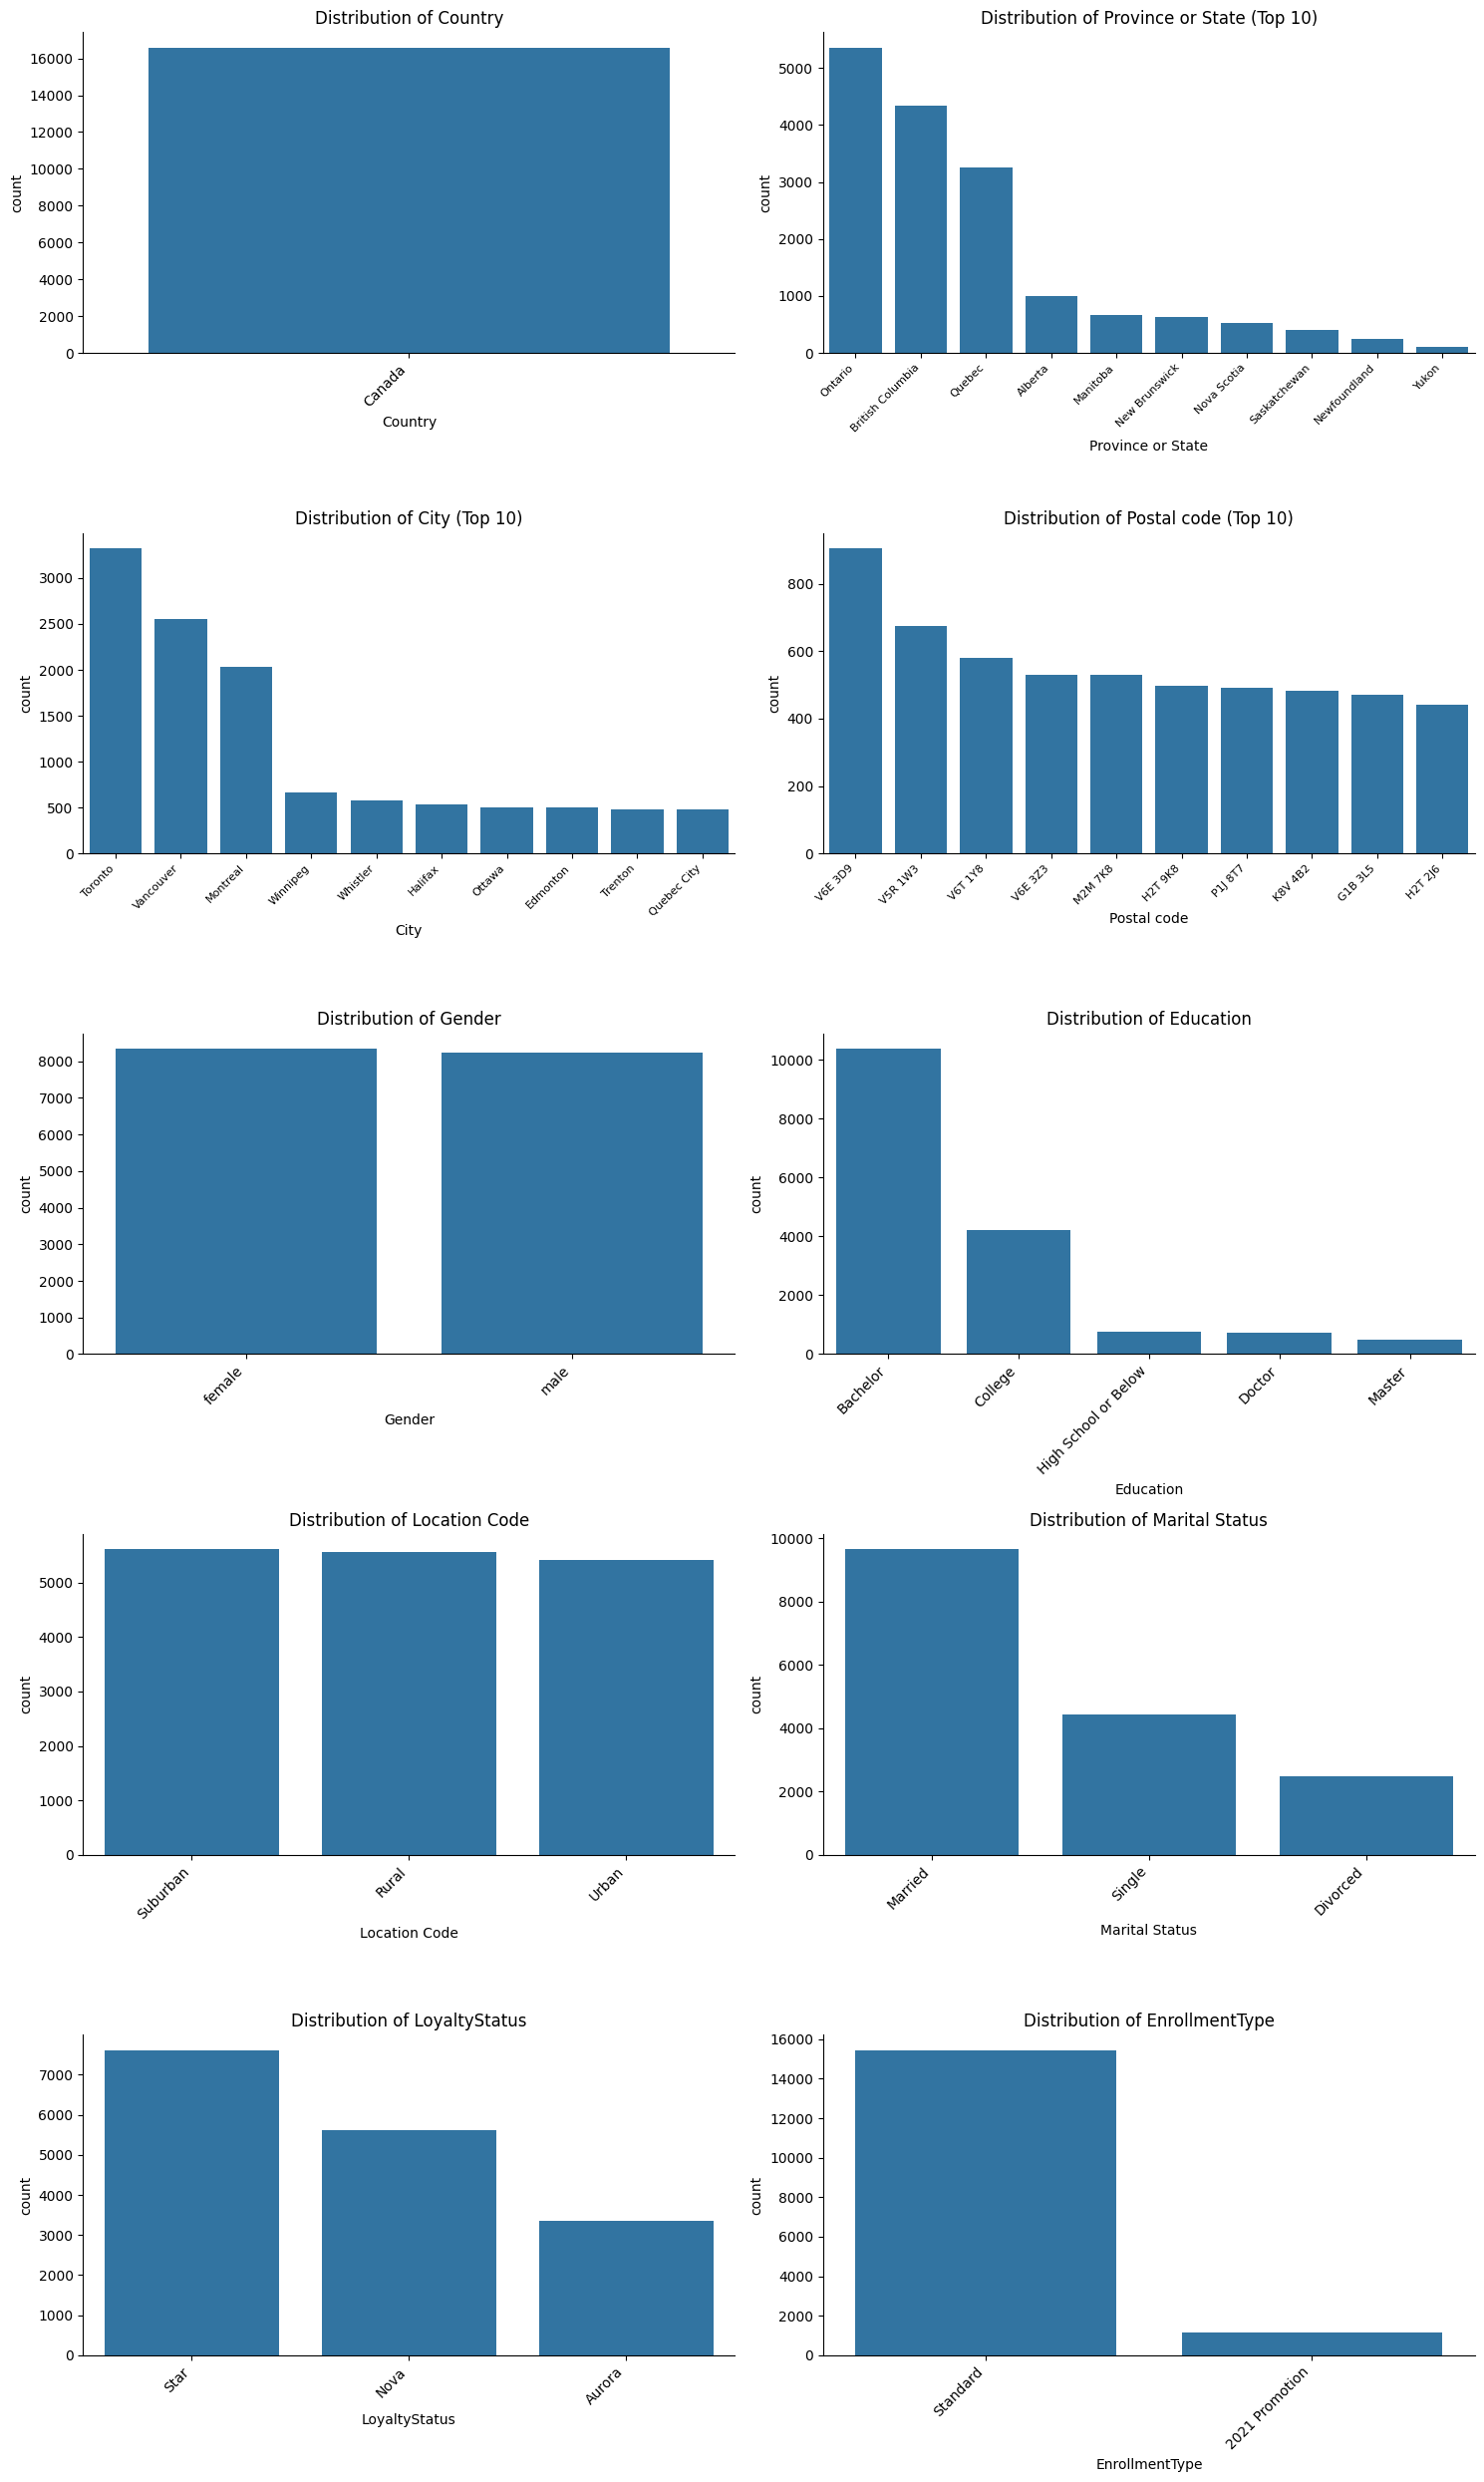

In [38]:
# Grid Layout for Categorical Features
n_cols = 2
n_rows = math.ceil(len(customers_cat.columns) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten() if isinstance(axes, (list, np.ndarray)) else [axes]

for i, col in enumerate(customers_cat.columns):
    ax = axes[i]
    value_counts = customers_cat[col].value_counts(dropna=False)

    # Limit number of categories for readability
    max_categories = 10
    if len(value_counts) > max_categories:
        top_cats = value_counts.head(max_categories)
        data = customers_cat[customers_cat[col].isin(top_cats.index)]
        order = top_cats.index
        ax.set_title(f'Distribution of {col} (Top {max_categories})')
    else:
        data = customers_cat
        order = value_counts.index
        ax.set_title(f'Distribution of {col}')

    sns.countplot(data=data, x=col, order=order, ax=ax)

    # Rotate and shrink if necessary
    label_count = len(order)
    label_size = 10 if label_count <= 6 else 8 if label_count <= 10 else 6
    ax.tick_params(axis='x', labelrotation=45, labelsize=label_size)

    # Right-align for readability
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')

# Hide empty axes
for j in range(len(customers_cat.columns), len(axes)):
    fig.delaxes(axes[j])

sns.despine(fig)
plt.tight_layout()
plt.show()


### 4.1.2 Customer EDA - Numerical Features  <a class="anchor" id="Customers-EDA-Numerical"></a>


In [39]:
# Filter for only numerical features
num_columns = customers.select_dtypes(include=np.number).columns.tolist()
customers_num = customers[num_columns]

# Remove Loyalty#, Latitude, Longitude from the list --> they are not useful for EDA
customers_num = customers_num.drop(columns=['Loyalty#', 'Latitude', 'Longitude'], errors='ignore')


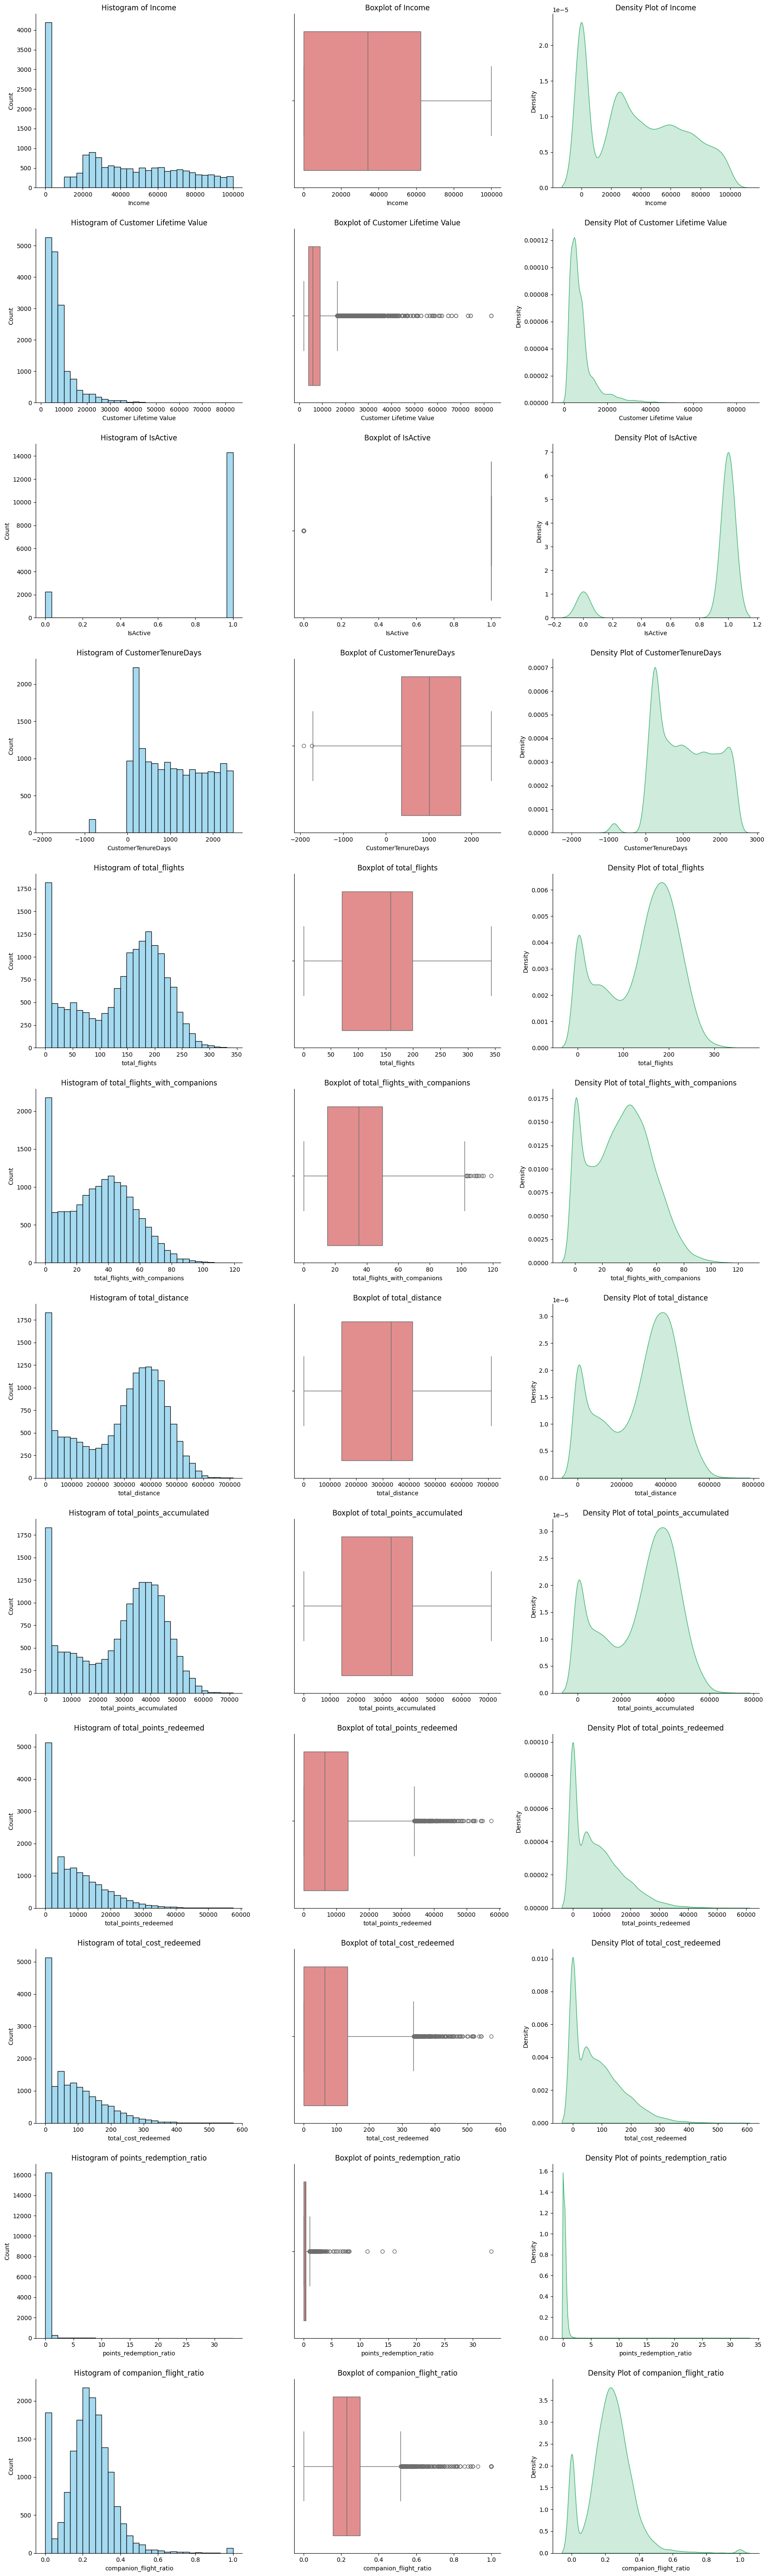

In [40]:
# Create a figure with 3 columns (hist, box, kde)
n_features = len(customers_num.columns)
n_cols = 3
n_rows = n_features

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))

# If there’s only one feature, make axes 2D
if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)

for i, col in enumerate(customers_num.columns):
    # Histogram
    sns.histplot(customers_num[col], bins=30, kde=False, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Histogram of {col}')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Count')

    # Boxplot
    sns.boxplot(x=customers_num[col], ax=axes[i, 1], color='lightcoral')
    axes[i, 1].set_title(f'Boxplot of {col}')
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel('')

    # Density plot (KDE)
    sns.kdeplot(customers_num[col].dropna(), ax=axes[i, 2], fill=True, color='mediumseagreen')
    axes[i, 2].set_title(f'Density Plot of {col}')
    axes[i, 2].set_xlabel(col)
    axes[i, 2].set_ylabel('Density')

plt.tight_layout()
sns.despine(fig)
plt.show()


### 4.1.2 Customer EDA - Multi-Variate Analysis  <a class="anchor" id="Customers-EDA-Multi-Variate"></a>


We do a multi-variate analysis of the numerical features to see if there are any correlations between them.

- We start with a correlation heatmap to see the correlations between the numerical features.

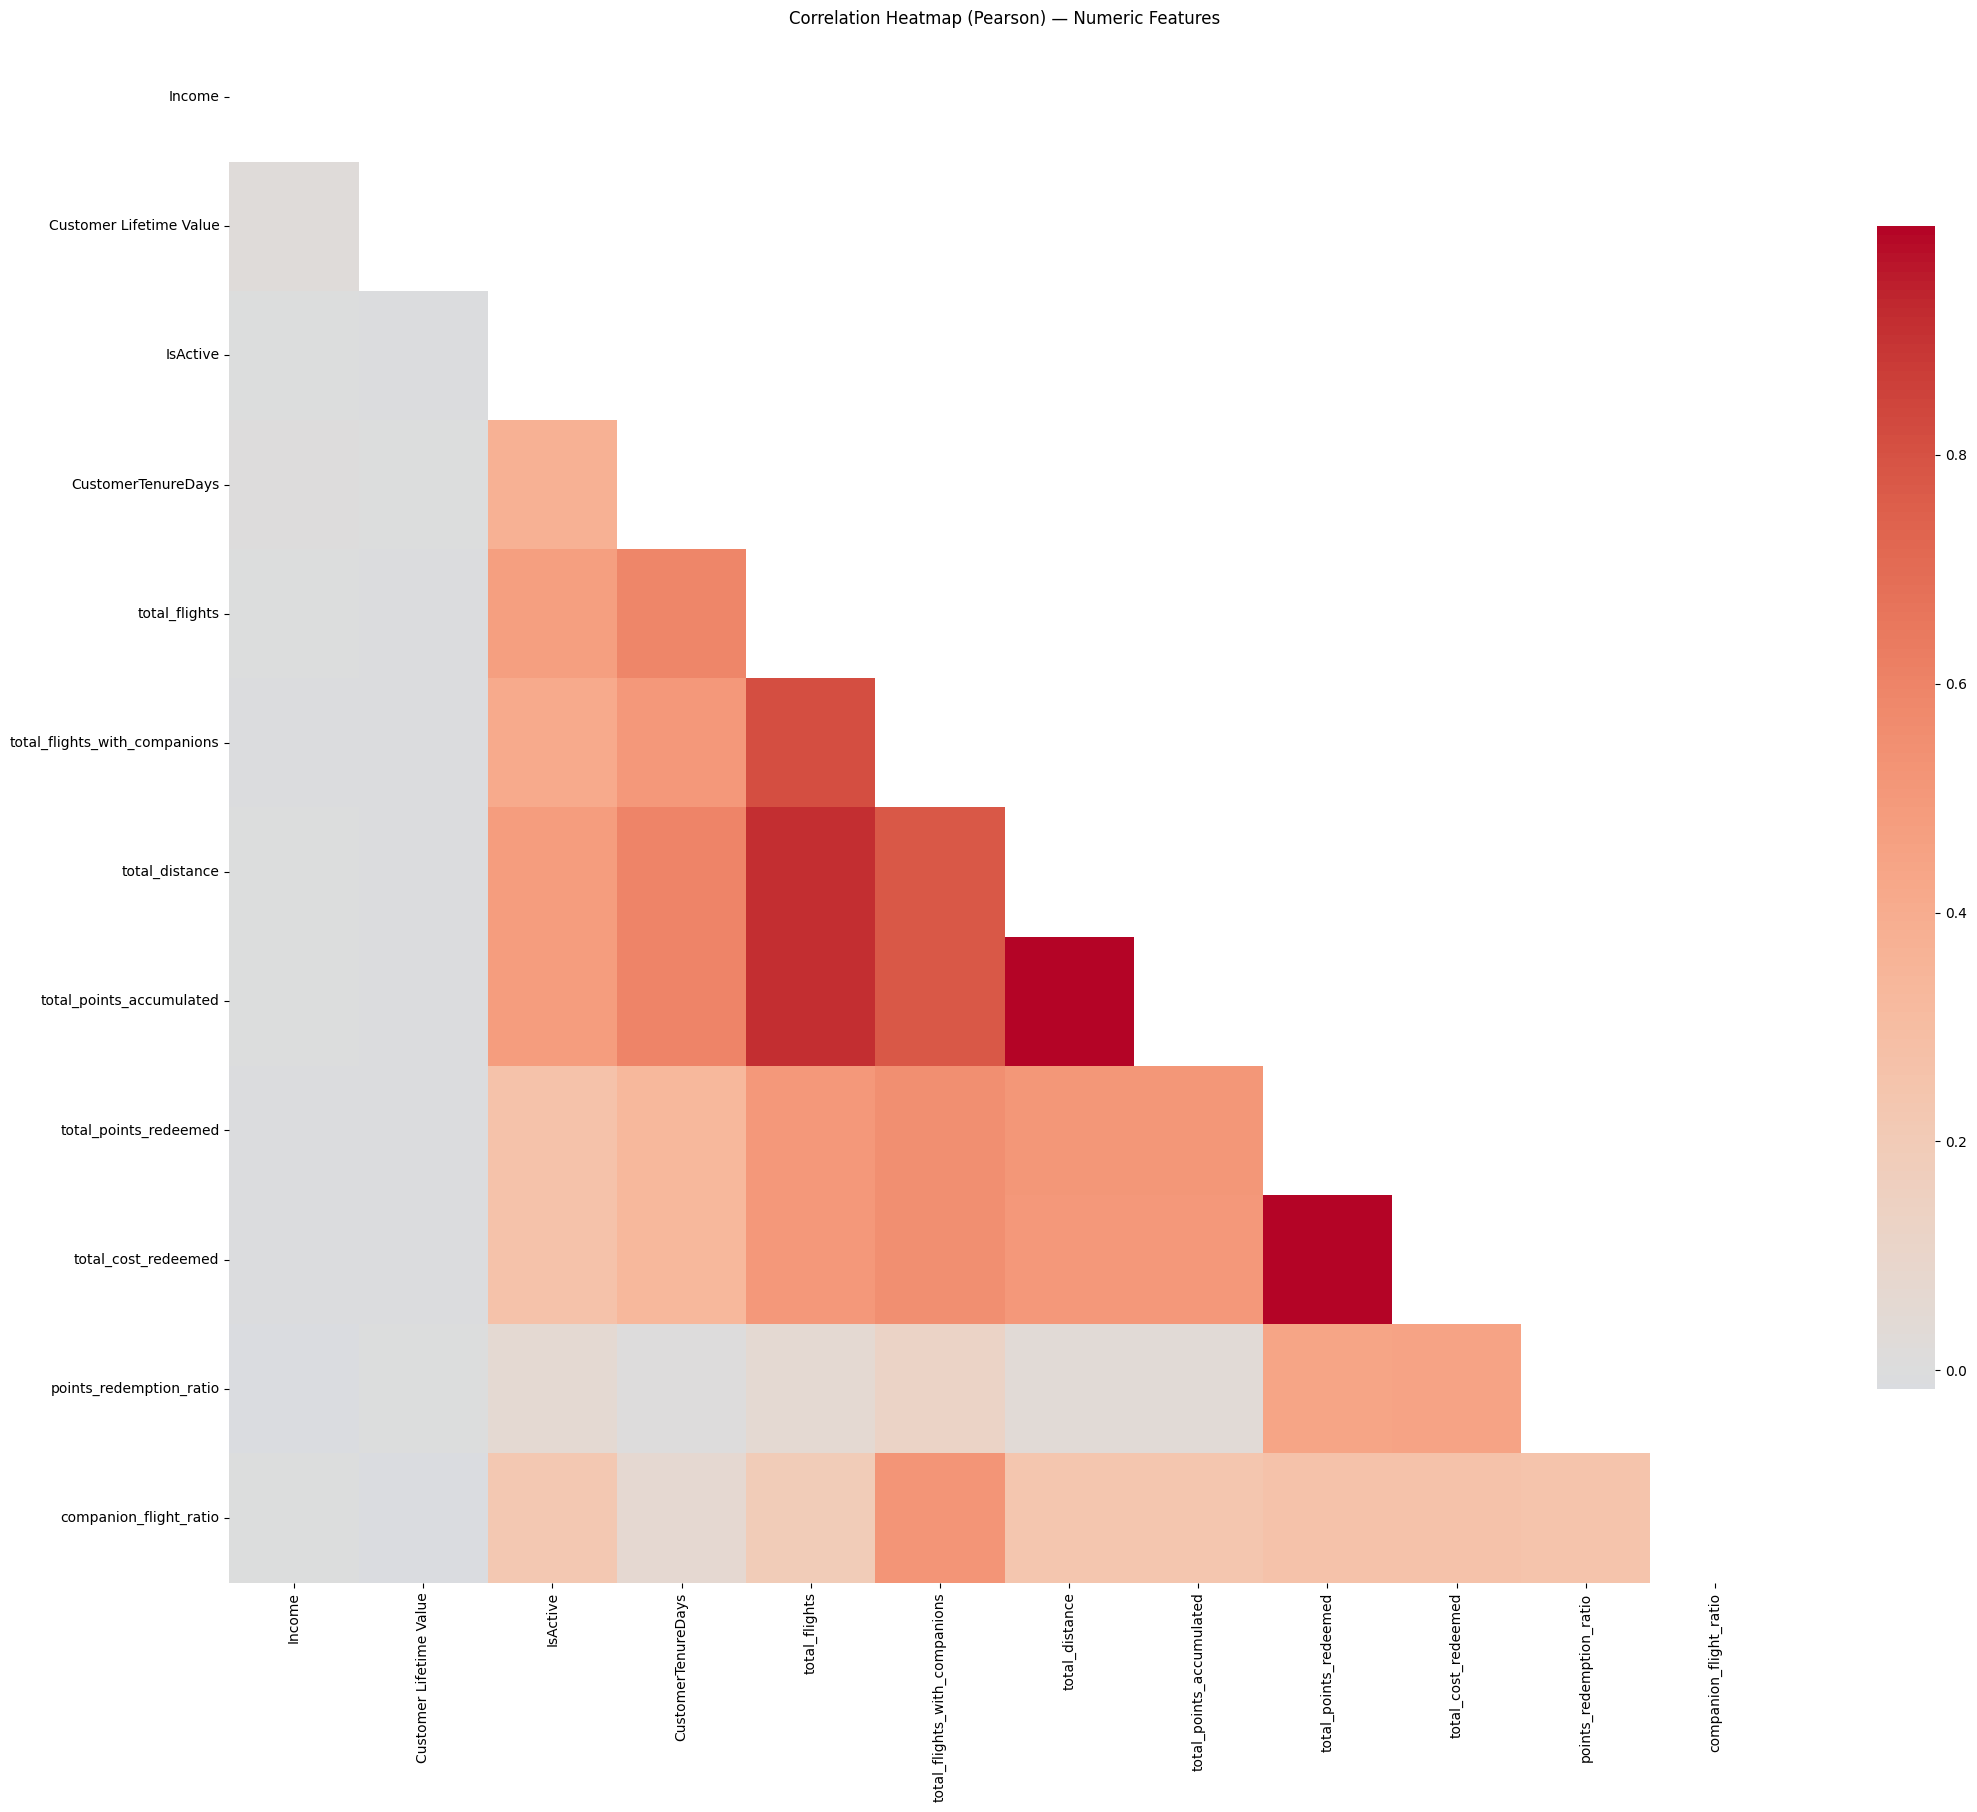

In [41]:
corr = customers_num.corr(method="pearson")

# mask upper triangle for readability
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(min(1.2*len(customers_num), 22), min(1.0*len(customers_num), 18)))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    annot=False,    # set True if you want numbers (can clutter)
    fmt=".2f",
    square=True,
    cbar_kws={"shrink": 0.75}
)
plt.title("Correlation Heatmap (Pearson) — Numeric Features")
plt.tight_layout()
plt.show()


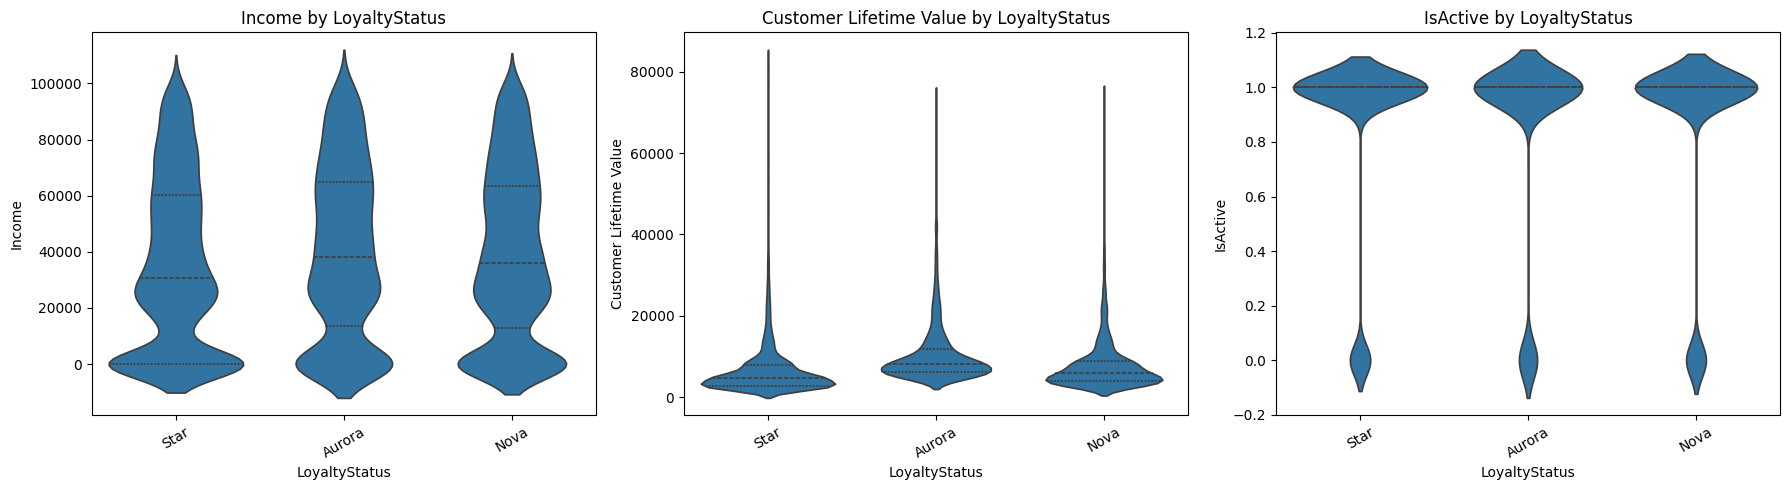

In [42]:
# Numeric vs Categorical — box/violin by LoyaltyStatus

cat_for_group = "LoyaltyStatus"
group_cols = customers_num.columns[:3]  # nutzt deine vordefinierten numerischen Spalten

# prüfen, ob alles vorhanden ist
if cat_for_group in customers.columns and len(group_cols) > 0:
    n_cols_subplot = 3
    n_rows_subplot = int(np.ceil(len(group_cols) / n_cols_subplot))

    fig, axes = plt.subplots(n_rows_subplot, n_cols_subplot, figsize=(18, 5 * n_rows_subplot))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(group_cols):
        ax = axes[i]
        sns.violinplot(
            data=customers,
            x=cat_for_group, 
            y=col, 
            inner="quartile", 
            ax=ax
        )
        ax.set_title(f"{col} by {cat_for_group}")
        ax.tick_params(axis='x', labelrotation=30)
        ax.set_xlabel(cat_for_group)
        ax.set_ylabel(col)

    # überzählige Subplots ausblenden
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print(f"'{cat_for_group}' not found or customers_num empty.")


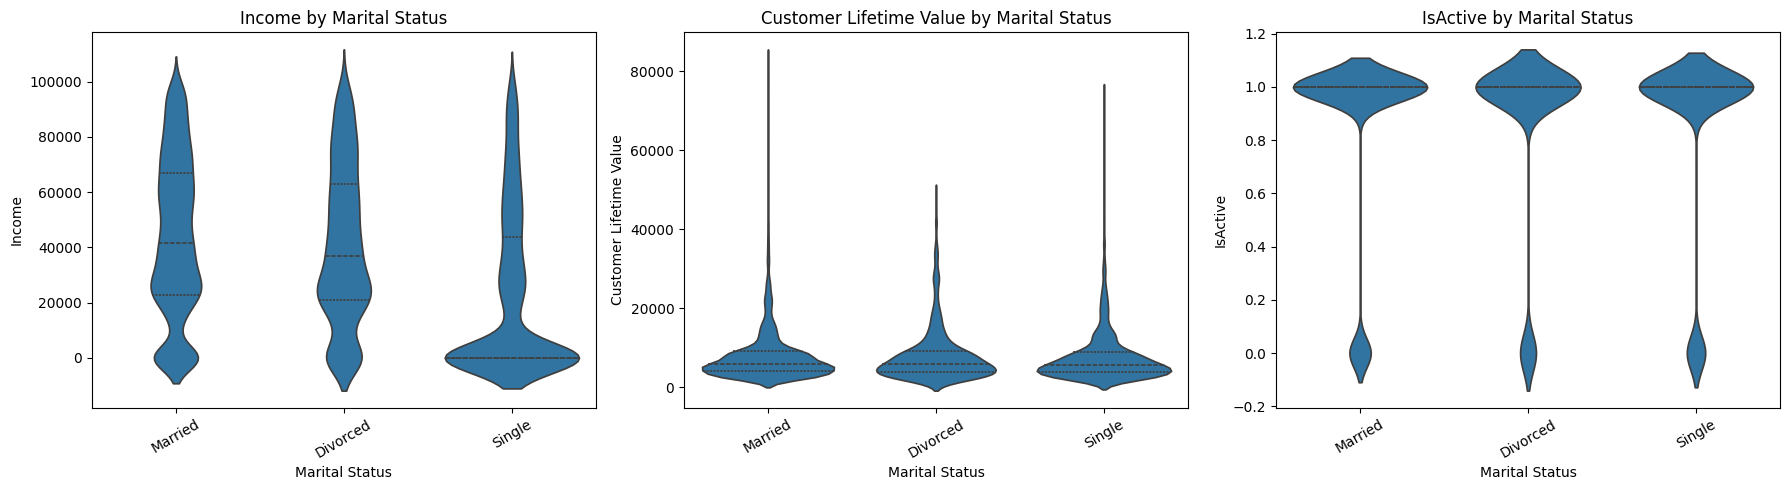

In [43]:
# Numeric vs Categorical — box/violin by Marital Status

cat_for_group = "Marital Status"   
group_cols = customers_num.columns[:3]  # nutzt deine vordefinierten numerischen Spalten

# prüfen, ob alles vorhanden ist
if cat_for_group in customers.columns and len(group_cols) > 0:
    n_cols_subplot = 3
    n_rows_subplot = int(np.ceil(len(group_cols) / n_cols_subplot))

    fig, axes = plt.subplots(n_rows_subplot, n_cols_subplot, figsize=(18, 5 * n_rows_subplot))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(group_cols):
        ax = axes[i]
        sns.violinplot(
            data=customers,
            x=cat_for_group, 
            y=col, 
            inner="quartile", 
            ax=ax
        )
        ax.set_title(f"{col} by {cat_for_group}")
        ax.tick_params(axis='x', labelrotation=30)
        ax.set_xlabel(cat_for_group)
        ax.set_ylabel(col)

    # überzählige Subplots ausblenden
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print(f"'{cat_for_group}' not found or customers_num empty.")


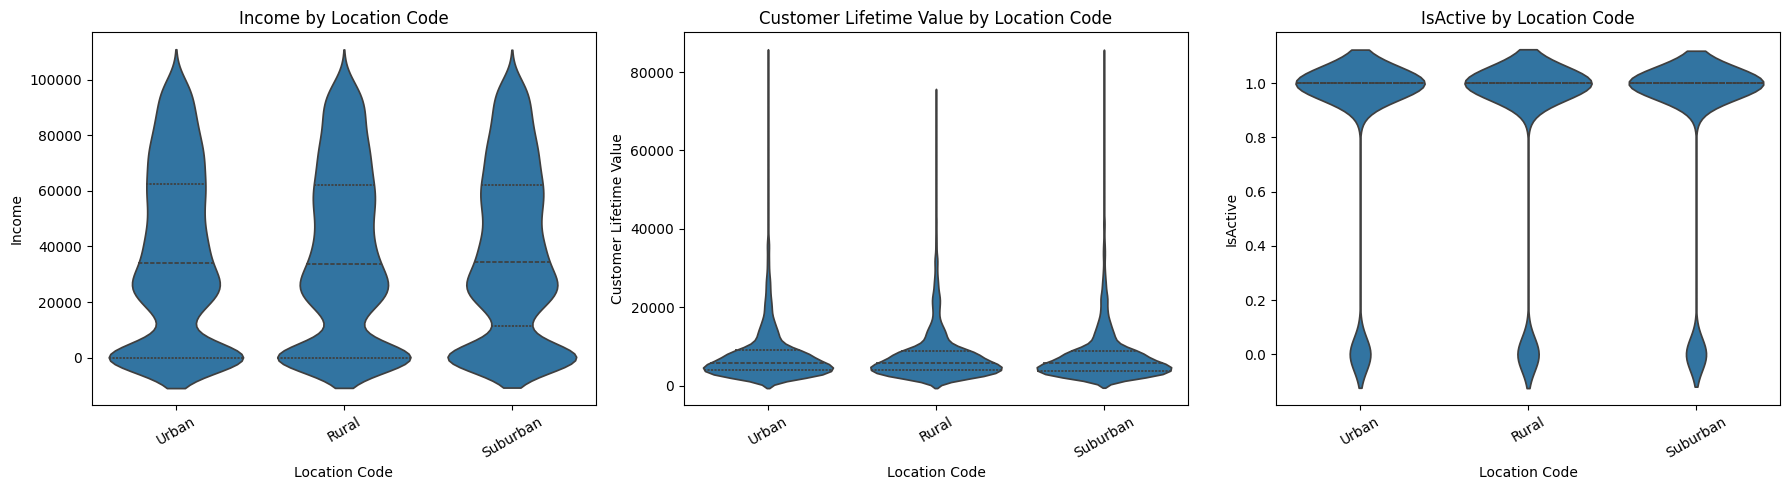

In [44]:
# Numeric vs Categorical — box/violin by Location Code

cat_for_group = "Location Code" 
group_cols = customers_num.columns[:3]  # nutzt deine vordefinierten numerischen Spalten

# prüfen, ob alles vorhanden ist
if cat_for_group in customers.columns and len(group_cols) > 0:
    n_cols_subplot = 3
    n_rows_subplot = int(np.ceil(len(group_cols) / n_cols_subplot))

    fig, axes = plt.subplots(n_rows_subplot, n_cols_subplot, figsize=(18, 5 * n_rows_subplot))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(group_cols):
        ax = axes[i]
        sns.violinplot(
            data=customers,
            x=cat_for_group, 
            y=col, 
            inner="quartile", 
            ax=ax
        )
        ax.set_title(f"{col} by {cat_for_group}")
        ax.tick_params(axis='x', labelrotation=30)
        ax.set_xlabel(cat_for_group)
        ax.set_ylabel(col)

    # überzählige Subplots ausblenden
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print(f"'{cat_for_group}' not found or customers_num empty.")


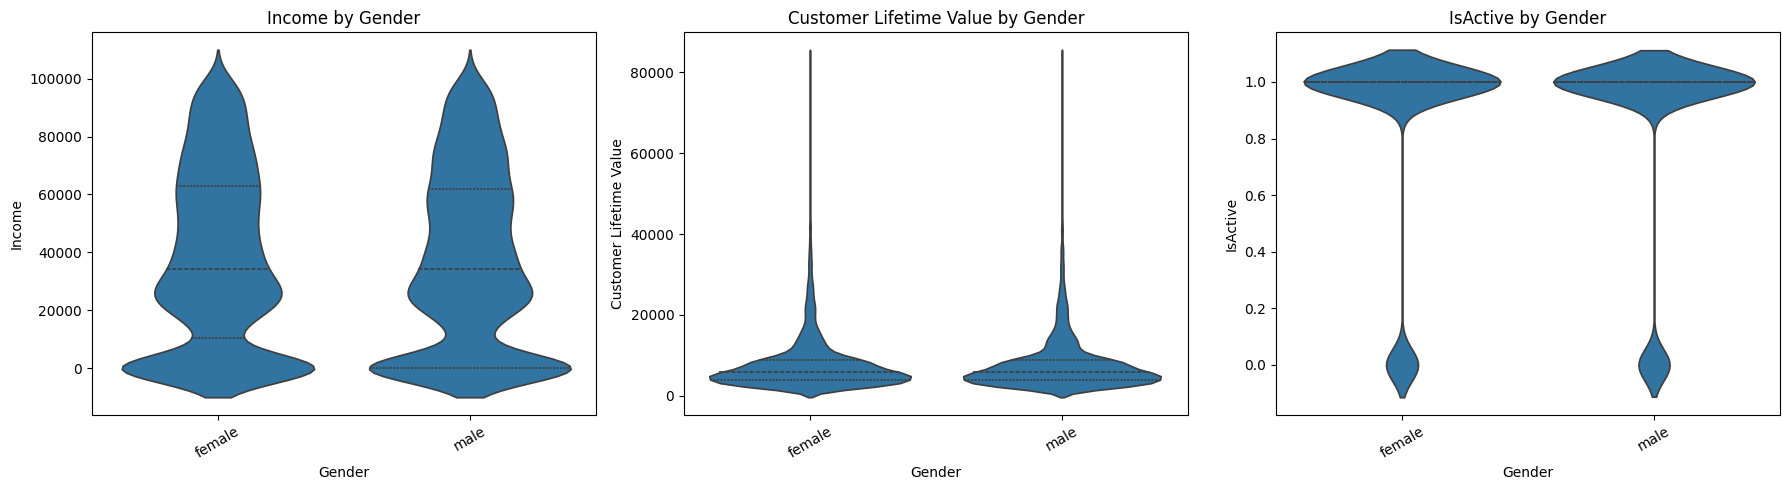

In [45]:
# Numeric vs Categorical — box/violin by Gender

cat_for_group = "Gender" 
group_cols = customers_num.columns[:3]  # nutzt deine vordefinierten numerischen Spalten

# prüfen, ob alles vorhanden ist
if cat_for_group in customers.columns and len(group_cols) > 0:
    n_cols_subplot = 3
    n_rows_subplot = int(np.ceil(len(group_cols) / n_cols_subplot))

    fig, axes = plt.subplots(n_rows_subplot, n_cols_subplot, figsize=(18, 5 * n_rows_subplot))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(group_cols):
        ax = axes[i]
        sns.violinplot(
            data=customers,
            x=cat_for_group, 
            y=col, 
            inner="quartile", 
            ax=ax
        )
        ax.set_title(f"{col} by {cat_for_group}")
        ax.tick_params(axis='x', labelrotation=30)
        ax.set_xlabel(cat_for_group)
        ax.set_ylabel(col)

    # überzählige Subplots ausblenden
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print(f"'{cat_for_group}' not found or customers_num empty.")


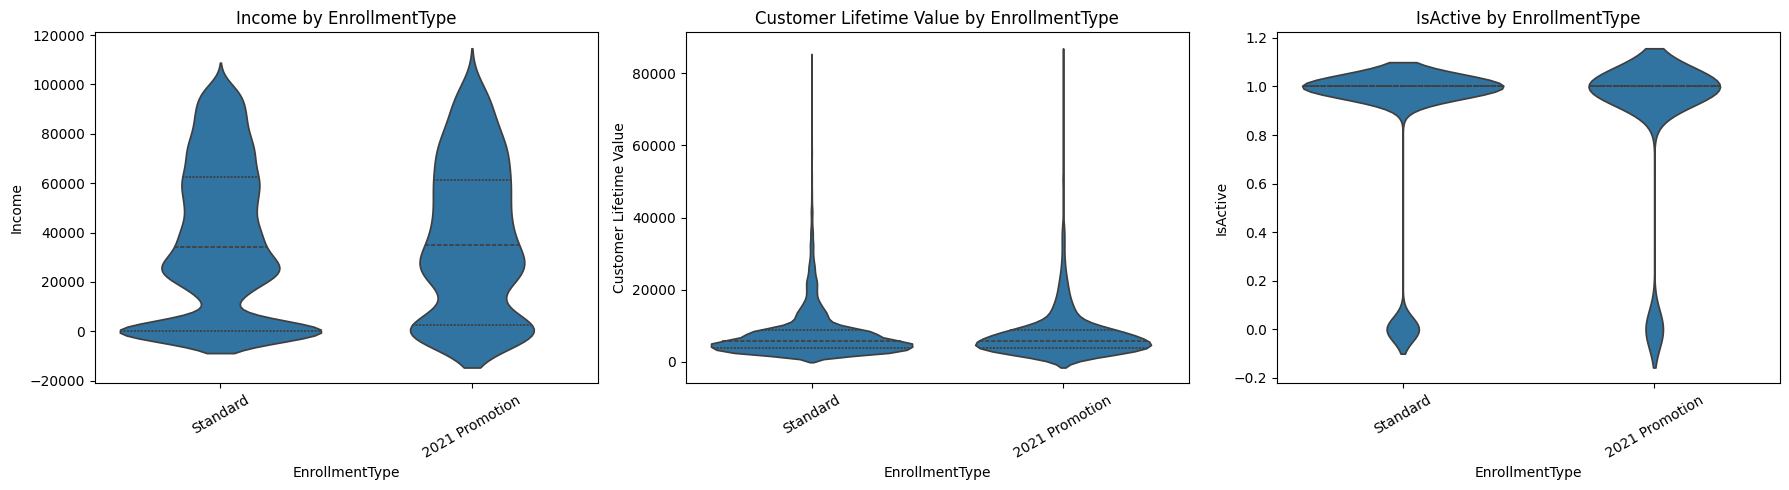

In [46]:
# Numeric vs Categorical — box/violin by EnrollmentType

cat_for_group = "EnrollmentType" 
group_cols = customers_num.columns[:3]  # nutzt deine vordefinierten numerischen Spalten

# prüfen, ob alles vorhanden ist
if cat_for_group in customers.columns and len(group_cols) > 0:
    n_cols_subplot = 3
    n_rows_subplot = int(np.ceil(len(group_cols) / n_cols_subplot))

    fig, axes = plt.subplots(n_rows_subplot, n_cols_subplot, figsize=(18, 5 * n_rows_subplot))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(group_cols):
        ax = axes[i]
        sns.violinplot(
            data=customers,
            x=cat_for_group, 
            y=col, 
            inner="quartile", 
            ax=ax
        )
        ax.set_title(f"{col} by {cat_for_group}")
        ax.tick_params(axis='x', labelrotation=30)
        ax.set_xlabel(cat_for_group)
        ax.set_ylabel(col)

    # überzählige Subplots ausblenden
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print(f"'{cat_for_group}' not found or customers_num empty.")


## 4.1 Flights EDA  <a class="anchor" id="Flights-EDA"></a>


We only have numerical features in the flights dataset and the datetime feature. So we will analyze them together.